# Exploración de Datos — Desconectados
## HackODS UNAM 2026 · Abejas Astutas

Este notebook realiza la exploración y el análisis descriptivo de los datos
procesados por `01_procesar_datos.ipynb`. Asume que `datos/estados.csv`,
`datos/nacional.csv` y `datos/tendencia_abandono.csv` ya existen.

Aquí también se construyen las visualizaciones preliminares que nutren el
storytelling del dashboard de Quarto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Paleta de colores consistente con el dashboard
C_RED   = "#c0392b"
C_AMBER = "#d97706"
C_GREEN = "#15803d"
C_BLUE  = "#1d4ed8"
C_MUTED = "#64748b"

DATA = "../datos"

estados    = pd.read_csv(f"{DATA}/estados.csv")
nacional   = pd.read_csv(f"{DATA}/nacional.csv").iloc[0]
tendencia  = pd.read_csv(f"{DATA}/tendencia_abandono.csv")

print(f"Estados cargados:  {len(estados)}")
print(f"Media nacional:    {nacional['media_nacional']:.1f}%")
print(f"Zona urbana:       {nacional['pct_urbano']:.1f}%")
print(f"Zona rural:        {nacional['pct_rural']:.1f}%")
print(f"Brecha rural-urb.: {nacional['brecha_ur']:.1f} pp")


Estados cargados:  32
Media nacional:    73.6%
Zona urbana:       79.7%
Zona rural:        48.5%
Brecha rural-urb.: 31.2 pp


## 1 · Estadísticas descriptivas

In [2]:
desc = estados[["internet_pct","pobreza_pct","abandono_pct","brecha"]].describe().round(2)
print(desc.to_string())


       internet_pct  pobreza_pct  abandono_pct  brecha
count         32.00        32.00         32.00   32.00
mean          73.11        42.05          9.31   26.89
std            9.10        14.38          2.64    9.10
min           50.70        19.70          4.68   15.60
25%           66.55        29.95          7.66   19.48
50%           75.10        44.15          9.26   24.90
75%           80.53        51.25         11.17   33.45
max           84.40        74.40         15.72   49.30


In [3]:
# Top 5 con más brecha digital
print("Estados con MENOR conectividad:")
print(estados.nsmallest(5,"internet_pct")[
    ["nombre","internet_pct","pobreza_pct","abandono_pct"]].to_string(index=False))

print()
print("Estados con MAYOR conectividad:")
print(estados.nlargest(5,"internet_pct")[
    ["nombre","internet_pct","pobreza_pct","abandono_pct"]].to_string(index=False))


Estados con MENOR conectividad:
  nombre  internet_pct  pobreza_pct  abandono_pct
 Chiapas          50.7         74.4          8.23
  Oaxaca          55.5         63.8         10.70
Guerrero          58.9         65.6          5.47
Tlaxcala          61.5         58.3          8.35
  Puebla          61.8         63.4          8.00

Estados con MAYOR conectividad:
           nombre  internet_pct  pobreza_pct  abandono_pct
Ciudad de MÃ©xico          84.4         34.2          9.79
           Sonora          84.4         31.2         11.12
      Nuevo LeÃ³n          83.7         19.7          7.60
         Coahuila          83.1         23.6          4.68
   Aguascalientes          82.4         27.5          8.75


## 2 · Correlación internet vs pobreza vs abandono

In [4]:
corr = estados[["internet_pct","pobreza_pct","abandono_pct","brecha"]].corr().round(3)
print("Matriz de correlación:")
print(corr.to_string())
print()
print(f"Correlación internet_pct ↔ pobreza_pct  : {corr.loc['internet_pct','pobreza_pct']:.3f}")
print(f"Correlación brecha       ↔ abandono_pct : {corr.loc['brecha','abandono_pct']:.3f}")


Matriz de correlación:
              internet_pct  pobreza_pct  abandono_pct  brecha
internet_pct         1.000       -0.815         0.076  -1.000
pobreza_pct         -0.815        1.000        -0.033   0.815
abandono_pct         0.076       -0.033         1.000  -0.076
brecha              -1.000        0.815        -0.076   1.000

Correlación internet_pct ↔ pobreza_pct  : -0.815
Correlación brecha       ↔ abandono_pct : -0.076


## 3 · Visualizaciones con matplotlib

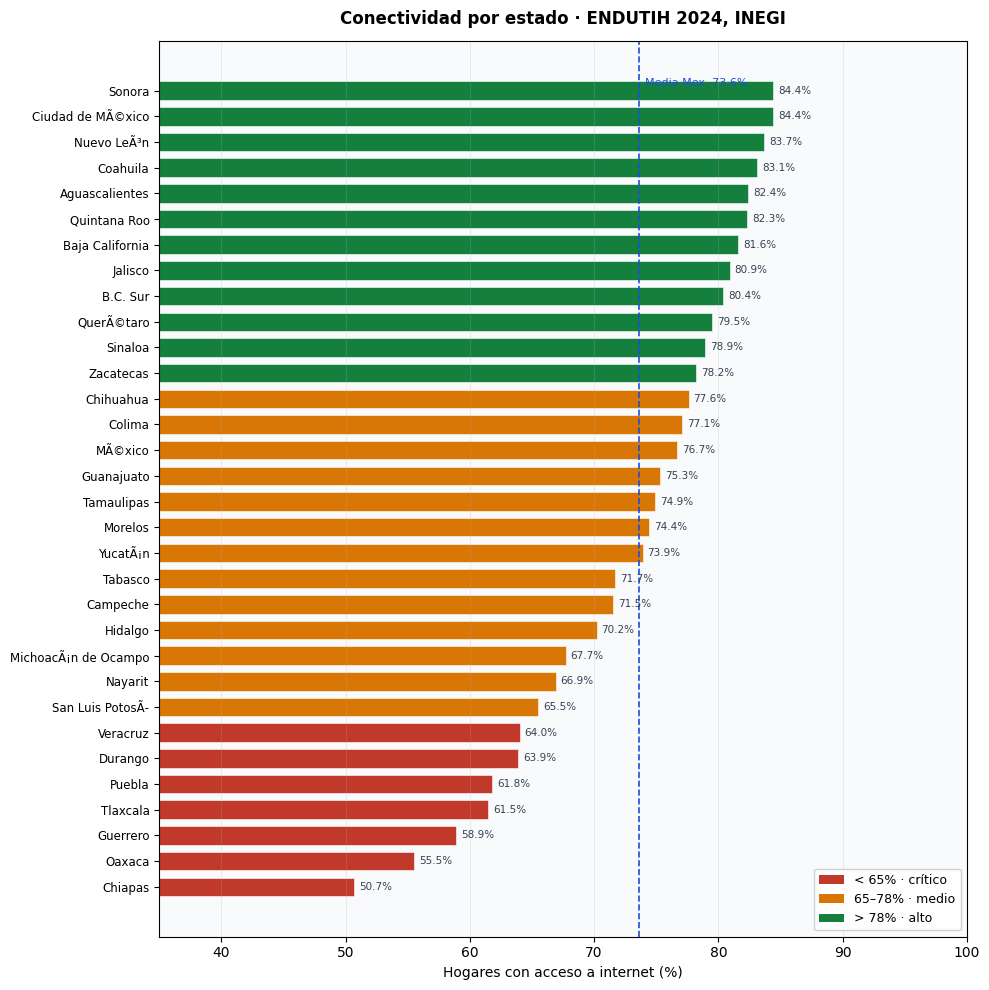

In [5]:
# ── Paleta de colores por región ─────────────────────────────────────────────
def color_region(pct):
    if pct < 65:   return C_RED
    if pct < 78:   return C_AMBER
    return C_GREEN

colores = estados["internet_pct"].apply(color_region).tolist()
estados_sorted = estados.sort_values("internet_pct")

# ── Figura 1: Barras de conectividad ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(estados_sorted["nombre"], estados_sorted["internet_pct"],
               color=estados_sorted["internet_pct"].apply(color_region),
               height=0.72, edgecolor="white", linewidth=0.4)

ax.axvline(nacional["media_nacional"], color=C_BLUE, linestyle="--", linewidth=1.2)
ax.text(nacional["media_nacional"]+0.5, 31.5,
        f"Media Mex. {nacional['media_nacional']:.1f}%",
        color=C_BLUE, fontsize=8, va="top")

# Etiquetas de valor
for bar, val in zip(bars, estados_sorted["internet_pct"]):
    ax.text(val+0.4, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=7.5, color="#374151")

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=C_RED,   label="< 65% · crítico"),
    Patch(facecolor=C_AMBER, label="65–78% · medio"),
    Patch(facecolor=C_GREEN, label="> 78% · alto"),
]
ax.legend(handles=leyenda, loc="lower right", fontsize=9, framealpha=0.9)

ax.set_xlabel("Hogares con acceso a internet (%)", fontsize=10)
ax.set_title("Conectividad por estado · ENDUTIH 2024, INEGI",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlim(35, 100)
ax.set_facecolor("#f8fafc")
ax.grid(axis="x", alpha=0.3, linewidth=0.5)
ax.tick_params(axis="y", labelsize=8.5)

plt.tight_layout()
plt.savefig(f"{DATA}/../scripts/fig_conectividad_barras.png", dpi=130, bbox_inches="tight")
plt.show()


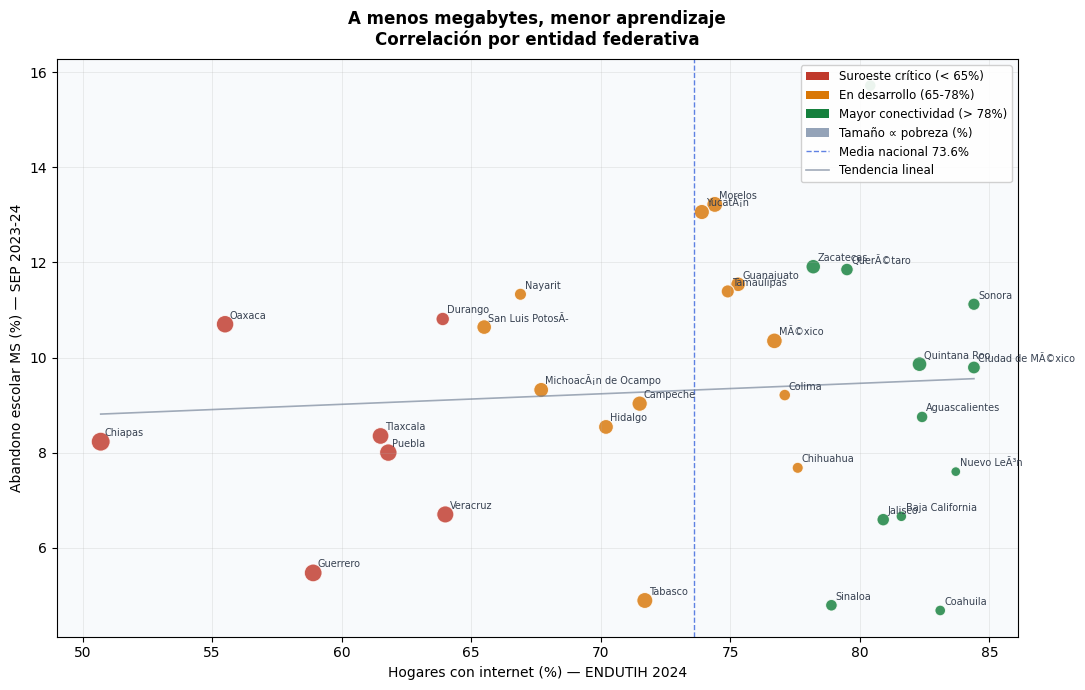

In [6]:
# ── Figura 2: Scatter internet vs abandono escolar ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

df_sc = estados.dropna(subset=["pobreza_pct"])
colores_sc = df_sc["internet_pct"].apply(color_region)
tamaños    = df_sc["pobreza_pct"] * 2.5

scatter = ax.scatter(
    df_sc["internet_pct"], df_sc["abandono_pct"],
    c=colores_sc, s=tamaños, alpha=0.82,
    edgecolors="white", linewidths=0.8
)

for _, row in df_sc.iterrows():
    ax.annotate(row["nombre"],
                (row["internet_pct"], row["abandono_pct"]),
                xytext=(3, 4), textcoords="offset points",
                fontsize=7, color="#374151")

ax.axvline(nacional["media_nacional"], color=C_BLUE, linestyle="--",
           linewidth=1, alpha=0.7, label=f"Media nacional {nacional['media_nacional']:.1f}%")

# Línea de tendencia
import numpy as np
m, b = np.polyfit(df_sc["internet_pct"], df_sc["abandono_pct"], 1)
x_line = np.linspace(df_sc["internet_pct"].min(), df_sc["internet_pct"].max(), 100)
ax.plot(x_line, m*x_line + b, color=C_MUTED, linestyle="-",
        linewidth=1.2, alpha=0.6, label="Tendencia lineal")

leyenda = [
    Patch(facecolor=C_RED,   label="Suroeste crítico (< 65%)"),
    Patch(facecolor=C_AMBER, label="En desarrollo (65-78%)"),
    Patch(facecolor=C_GREEN, label="Mayor conectividad (> 78%)"),
    Patch(facecolor="#94a3b8", label="Tamaño ∝ pobreza (%)"),
]
ax.legend(handles=leyenda + [ax.lines[0], ax.lines[1]],
          fontsize=8.5, framealpha=0.9, loc="upper right")

ax.set_xlabel("Hogares con internet (%) — ENDUTIH 2024", fontsize=10)
ax.set_ylabel("Abandono escolar MS (%) — SEP 2023-24", fontsize=10)
ax.set_title("A menos megabytes, menor aprendizaje\nCorrelación por entidad federativa",
             fontsize=12, fontweight="bold", pad=10)
ax.set_facecolor("#f8fafc")
ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{DATA}/../scripts/fig_scatter_abandono.png", dpi=130, bbox_inches="tight")
plt.show()


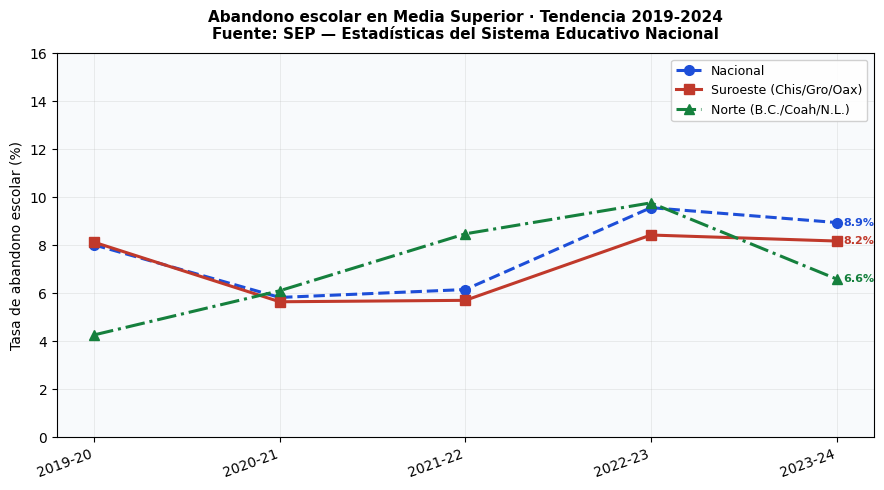

In [7]:
# ── Figura 3: Tendencia histórica abandono MS ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

series_config = {
    "Nacional":                 (C_BLUE,  "--", "o"),
    "Suroeste (Chis/Gro/Oax)": (C_RED,   "-",  "s"),
    "Norte (B.C./Coah/N.L.)":  (C_GREEN, "-.", "^"),
}
etiquetas_x = {2020:"2019-20",2021:"2020-21",2022:"2021-22",
               2023:"2022-23",2024:"2023-24"}

for serie, (color, ls, marker) in series_config.items():
    ax.plot(tendencia["anio"], tendencia[serie],
            color=color, linestyle=ls, marker=marker,
            linewidth=2.2, markersize=7, label=serie)
    # Etiqueta en el punto final
    last_val = tendencia[serie].iloc[-1]
    ax.annotate(f"{last_val:.1f}%", (2024, last_val),
                xytext=(5, 0), textcoords="offset points",
                color=color, fontsize=8, va="center", fontweight="bold")

ax.set_xticks(tendencia["anio"])
ax.set_xticklabels(list(etiquetas_x.values()), rotation=20, ha="right")
ax.set_ylabel("Tasa de abandono escolar (%)", fontsize=10)
ax.set_title("Abandono escolar en Media Superior · Tendencia 2019-2024\n"
             "Fuente: SEP — Estadísticas del Sistema Educativo Nacional",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_facecolor("#f8fafc")
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_ylim(0, 16)

plt.tight_layout()
plt.savefig(f"{DATA}/../scripts/fig_tendencia_abandono.png", dpi=130, bbox_inches="tight")
plt.show()


## 4 · Resumen de hallazgos

In [8]:
suroeste = estados[estados["CVE_ENT"].isin([7, 12, 20, 30])]
norte    = estados[estados["CVE_ENT"].isin([2, 5, 19, 8])]

print("=" * 55)
print("HALLAZGOS PRINCIPALES")
print("=" * 55)
print(f"Internet promedio suroeste : {suroeste['internet_pct'].mean():.1f}%")
print(f"Internet promedio norte    : {norte['internet_pct'].mean():.1f}%")
print(f"Diferencia                 : {norte['internet_pct'].mean() - suroeste['internet_pct'].mean():.1f} pp")
print()
print(f"Pobreza promedio suroeste  : {suroeste['pobreza_pct'].mean():.1f}%")
print(f"Pobreza promedio norte     : {norte['pobreza_pct'].mean():.1f}%")
print()
print(f"Abandono promedio suroeste : {suroeste['abandono_pct'].mean():.2f}%")
print(f"Abandono promedio norte    : {norte['abandono_pct'].mean():.2f}%")
print()
print(f"Brecha rural-urbana 2024   : {nacional['brecha_ur']:.1f} pp")
print(f"  Zona urbana              : {nacional['pct_urbano']:.1f}%")
print(f"  Zona rural               : {nacional['pct_rural']:.1f}%")
print("=" * 55)


HALLAZGOS PRINCIPALES
Internet promedio suroeste : 57.3%
Internet promedio norte    : 81.5%
Diferencia                 : 24.2 pp

Pobreza promedio suroeste  : 66.2%
Pobreza promedio norte     : 23.0%

Abandono promedio suroeste : 7.77%
Abandono promedio norte    : 6.65%

Brecha rural-urbana 2024   : 31.2 pp
  Zona urbana              : 79.7%
  Zona rural               : 48.5%
